In [1]:
import os

if os.getcwd().split("/")[-1] != "neurolib":
    os.chdir('..')

os.chdir('..')
datadir = os.path.join(os.getcwd(), "neurolib", "whole-brain")
print(datadir)

/home/lena/Promotion/neurolib/neurolib/whole-brain


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
import pickle

from neurolib.models.wc import WCModel
from neurolib.control.optimal_control import oc_wc, cost_functions

import nctpy.utils
import nctpy.metrics
import pandas as pd
import seaborn as sns

# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

import matplotlib as mpl
label_size= 20
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
mpl.rcParams['font.size'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['figure.titlesize'] = label_size
mpl.rcParams['lines.linewidth'] = 1


def ploterrorrange(x_axis, linfit, linfitstd):
    xpos = np.linspace(0., x_axis[-1], 100)
    a.fill_between(xpos, linfit[1]-linfitstd[1] + xpos*(linfit[0]-linfitstd[0]), linfit[1] + xpos*linfit[0], color="red", alpha=0.3 )
    a.fill_between(xpos, linfit[1] + xpos*linfit[0], linfit[1]+linfitstd[1] + xpos*(linfit[0]+linfitstd[0]), color="red", alpha=0.3 )
    xneg = np.linspace(x_axis[0], -1e-3, 100, )
    a.fill_between(xneg, linfit[1]-linfitstd[1] + xneg*(linfit[0]+linfitstd[0]), linfit[1] + xneg*linfit[0], color="red", alpha=0.3 )
    a.fill_between(xneg, linfit[1] + xneg*linfit[0], linfit[1]+linfitstd[1] + xneg*(linfit[0]-linfitstd[0]), color="red", alpha=0.3 )

In [3]:
N = 100

folders = ["NAP_002", "NAP_003", "NAP_005", "NAP_007", "NAP_009", "NAP_010", "NAP_011", "NAP_012", "NAP_013", "NAP_014", "NAP_015", "NAP_016", "NAP_018", "NAP_020", "NAP_022", "NAP_024", "NAP_025", "NAP_026", "NAP_027", "NAP_028", "NAP_029", "NAP_031", "NAP_032", "NAP_033", "NAP_035", "NAP_036"]
cmat_sum = np.zeros((N,N))
dmat_sum = np.zeros((N,N))

for f in folders:
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_CM.mat")
    cmat_sum += scipy.io.loadmat(path)["SC"]
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_LEN.mat")
    dmat_sum += scipy.io.loadmat(path)["LEN"]

cmat_av = cmat_sum/len(folders)
dmat_av = dmat_sum/len(folders)

coord_data = pd.read_csv(os.path.join(os.getcwd(), "data", "structural_data", "Sch100_coords.txt"), sep=None, header=None).to_numpy()

/tmp/ipykernel_2504169/854259224.py:16: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support sep=None with delim_whitespace=False; you can avoid this warning by specifying engine='python'.
  coord_data = pd.read_csv(os.path.join(os.getcwd(), "data", "structural_data", "Sch100_coords.txt"), sep=None, header=None).to_numpy()


In [4]:
with open(os.path.join(datadir, 'wb_L1.pickle'), 'rb') as f:
    data_read = pickle.load(f)

[data_0, data_1, data_2] = data_read

dt = 0.1

rng = np.random.default_rng()
method = scipy.stats.PermutationMethod(n_resamples=2. * 1e3, random_state=rng)
cmap = "cividis"

0.0 0.11698083331378895
0.0 0.9696351553448196
0.0 1.7585529519107248
[[array([99, 36])], [65], [88]]


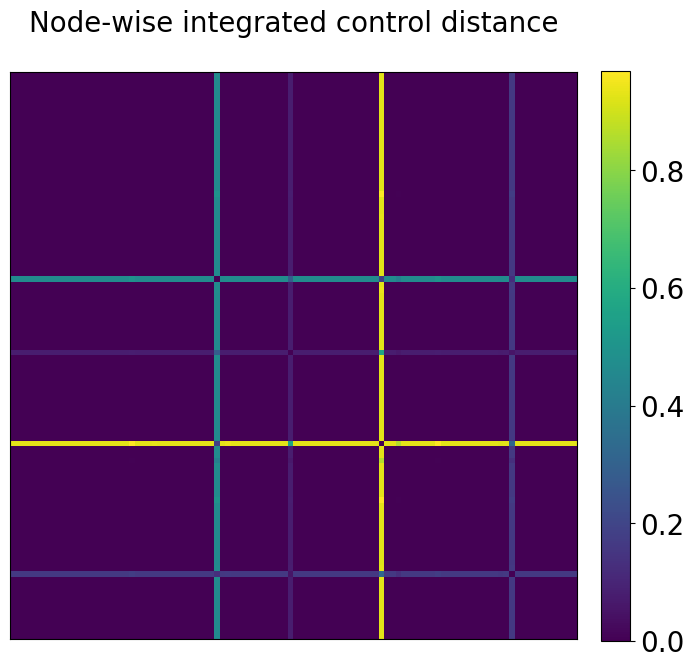

In [5]:
sys = "discrete"

c_norm = nctpy.utils.matrix_normalization((cmat_av), system=sys)
av_c = nctpy.metrics.ave_control(c_norm, sys)
mod_c = nctpy.metrics.modal_control(c_norm)
wnd = np.sum(cmat_av, axis=0)
nfl = np.sum(dmat_av, axis=0)

nfl -= np.amin(nfl)
nfl /= 1e3

wnfl = np.zeros((N))
for n in range(N):
    wnfl[n] = sum(cmat_av[n,:]*dmat_av[n,:])

peak_times = np.zeros((N))

for n in range(N):
    peak_times[n] = scipy.signal.find_peaks(data_0["state_uncontrolled"][n,0,:], height=0.7)[0][-1]

peak_times -= np.amin(peak_times)
peak_times *= dt

peak_times0 = peak_times.copy()

peak_time_order0 = np.argsort(peak_times)

energy_nodewise = np.zeros((3,N))
input_nodewise = np.zeros((3,N))
for wi in range(3):
    for n in range(N):
        energy_nodewise[wi,n] = np.sum(data_0["control"][wi][n,0,:])**2 * dt
        input_nodewise[wi,n] = np.sum(data_0["control"][wi][n,0,:]) * dt

distmat = np.zeros((3,N,N))
cnd = np.zeros((3,N))
mdn = [[], [], []]

for wi in range(3):
    for n1 in range(N):
        for n2 in range(n1+1, N):
            distmat[wi,n1,n2] = np.sum( (data_0["control"][wi][n1,0,:] - data_0["control"][wi][n2,0,:])**2 )*dt
            distmat[wi,n2,n1] = distmat[wi,n1,n2].copy()

    cnd[wi,:] = np.sum(distmat[wi,:,:], axis=0)
    if wi == 0:
        mdn[wi].append(np.argsort(cnd[wi,:])[-2:])
    else:
        mdn[wi].append(np.argsort(cnd[wi,:])[-1])
        
    print(np.amin(distmat[wi,:,:]), np.amax(distmat[wi,:,:]))
print(mdn)

fig, ax = plt.subplots(1,1, figsize=(8,8))
heatmap = ax.imshow(distmat[1,:,:])
bar = plt.colorbar(heatmap, fraction=0.046, pad=0.04)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Node-wise integrated control distance\n")
plt.savefig(os.path.join(datadir, "control_dist.jpg"), bbox_inches='tight', dpi=300)
plt.show()

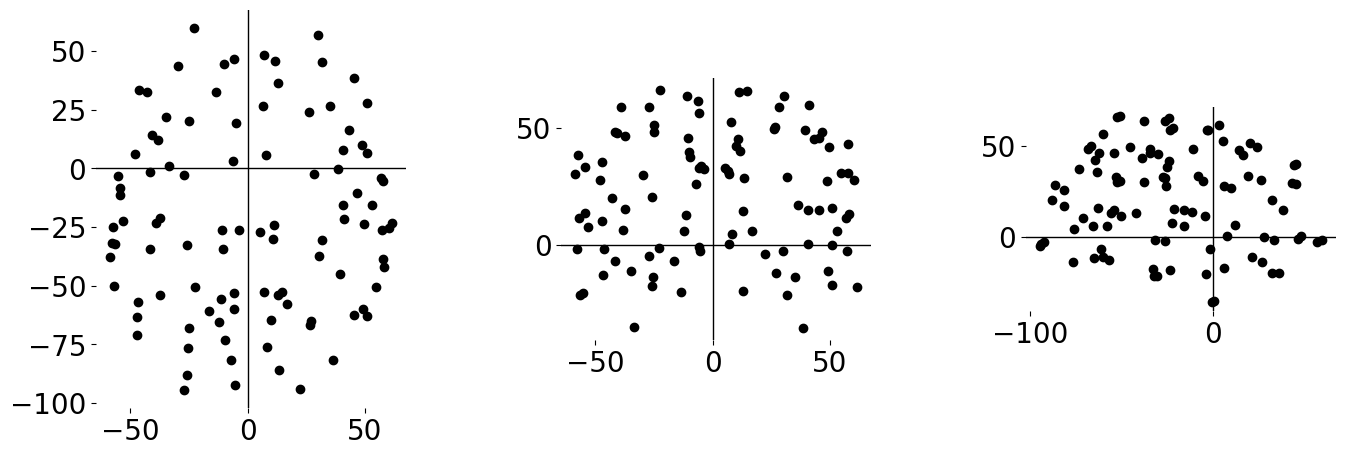

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(16,6))

for n in range(N):
    ax[0].plot(coord_data[n,0], coord_data[n,1], marker="o", color="k")
    ax[1].plot(coord_data[n,0], coord_data[n,2], marker="o", color="k")
    ax[2].plot(coord_data[n,1], coord_data[n,2], marker="o", color="k")


for k in range(3):
    ax[k].set_aspect('equal', adjustable='box')
    ax[k].axhline(y=0, color='k')
    ax[k].axvline(x=0, color='k')

    #ax[k].get_xaxis().set_visible(False)

    ax[k].spines['right'].set_visible(False)
    ax[k].spines['left'].set_visible(False)
    ax[k].spines['top'].set_visible(False)
    ax[k].spines['bottom'].set_visible(False)

plt.subplots_adjust(left=None, bottom=0.1, right=None, top=None, wspace=0.5, hspace=0.1)
plt.box(False)
plt.show()

In [7]:
x_array = [av_c, wnd, nfl, coord_data[:,0], coord_data[:,1], coord_data[:,2]]
xlabel = ["Average controllability", "Weighted node degree", "Relative fiber length", "x coordinate", "y coordinate", "z coordinate"]
ylabel = ["Oscillation peak time", "Node energy input", "Node control difference"]

wi = 2
y_array = [peak_times0, energy_nodewise[wi,:], cnd[wi,:]]

r_mat_sc_cd_0 = np.zeros((len(x_array), len(y_array)))
p_mat_sc_cd_0 = np.zeros((len(x_array), len(y_array)))

for ix, x in enumerate(x_array):
    for iy, y in enumerate(y_array):

        result = scipy.stats.pearsonr(x, y, method=method)
        r_val = result.statistic
        p_val = result.pvalue
        r_mat_sc_cd_0[ix, iy] = r_val
        p_mat_sc_cd_0[ix, iy] = p_val

if False:

    fig, ax = plt.subplots(len(y_array),len(x_array), figsize=(8*len(x_array), 8*len(y_array)))

    for ix, x in enumerate(x_array):

        for iy, y in enumerate(y_array):

            a = ax[iy,ix]

            a.plot(x, y, marker="x", color="k", linestyle="none")
            x_axis = np.linspace(np.amin(x)*0.95, np.amax(x)*1.05, 100)
            
            a.plot(x[mdn[wi]], y[mdn[wi]], marker="o", color="green", linestyle="none", markersize=10)

            result = scipy.stats.pearsonr(x, y, method=method)
            r_val = result.statistic
            p_val = result.pvalue
            corrstr = " r = {0:.3f}, p = {1:.3f}".format(r_val, p_val)

            a.text(0.9, 0.9, corrstr, horizontalalignment='right', verticalalignment='center', transform=a.transAxes)

            if p_val < 0.05 and np.abs(r_val) > 0.4:

                linfit, linfitcov = np.polyfit(x, y, 1, cov=True)
                linfitstd = np.sqrt(np.diag(linfitcov))

                if np.sign(linfit[0]) < 0:
                    a.plot(x_axis, linfit[1] + x_axis*linfit[0], color="red", label= r"$y = $" + "{:.2f}".format(linfit[1]) + r"$-$" + "{:.2f}".format(-linfit[0]) + "$\cdot x$", zorder=-1)
                else:
                    a.plot(x_axis, linfit[1] + x_axis*linfit[0], color="red", label= r"$y = $" + "{:.2f}".format(linfit[1]) + r"$+$" + "{:.2f}".format(linfit[0]) + "$\cdot x$", zorder=-1)
                ploterrorrange(x_axis, linfit, linfitstd)
                    
                #a.plot([-100, -99], [-100,-99], color="white", linestyle="none", marker=None, label=r"std = " + "{:.2f}".format(100.*linfitstd[0]/np.abs(linfit[0])) + r" %")
                
                #a.legend(loc="upper right", fancybox=True, framealpha=0.0)

                a.set_xlim(x_axis[0], x_axis[-1])
                a.set_ylim(0, np.amax(y)*1.05)
            
            if iy == 2:
                a.set_xlabel(xlabel[ix])
            else:
                a.set_xticklabels([])

            if ix == 0:
                a.set_ylabel(ylabel[iy])
            else:
                a.set_yticklabels([])
            
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.1, hspace=0.1)
    plt.savefig(os.path.join(datadir, "sc_cd_measures_0.jpg"), bbox_inches='tight', dpi=300)
    plt.show()

if False:
    x_array = [av_c, wnd, nfl, coord_data[:,2]]
    xlabel = ["Average controllability - 1", "Weighted node degree", "Relative fiber length", "z coordinate"]
    ylabel = ["Oscillation peak time"]

    fig, ax = plt.subplots(1,len(x_array), figsize=(8*len(x_array), 8))

    y_array = [peak_times]

    for ix, x in enumerate(x_array):

        for iy, y in enumerate(y_array):
        
            a = ax[ix]

            a.plot(x, y, marker="x", color="k", linestyle="none")
            x_axis = np.linspace(np.amin(x)*0.95, np.amax(x)*1.05, 100)
            
            a.plot(x[mdn[wi]], y[mdn[wi]], marker="o", color="green", linestyle="none", markersize=10)
            
            result = scipy.stats.pearsonr(x, y, method=method)
            r_val = result.statistic
            p_val = result.pvalue
            corrstr = " r = {0:.3f}, p = {1:.3f}".format(r_val, p_val)

            a.text(0.9, 0.9, corrstr, horizontalalignment='right', verticalalignment='center', transform=a.transAxes)

            linfit, linfitcov = np.polyfit(x, y, 1, cov=True)
            linfitstd = np.sqrt(np.diag(linfitcov))
            #print(linfit, np.sqrt(np.diag(linfitcov)))

            
            if np.sign(linfit[0]) < 0:
                a.plot(x_axis, linfit[1] + x_axis*linfit[0], color="red", label= r"$y = $" + "{:.2f}".format(linfit[1]) + r"$-$" + "{:.2f}".format(-linfit[0]) + "$\cdot x$", zorder=-1)
            else:
                a.plot(x_axis, linfit[1] + x_axis*linfit[0], color="red", label= r"$y = $" + "{:.2f}".format(linfit[1]) + r"$+$" + "{:.2f}".format(linfit[0]) + "$\cdot x$", zorder=-1)
            ploterrorrange(x_axis, linfit, linfitstd)
            
            #a.plot([-100, -99], [-100,-99], color="white", linestyle="none", marker=None, label=r"std = " + "{:.2f}".format(100.*linfitstd[0]/np.abs(linfit[0])) + r" %")
            
            #a.legend(loc="upper right", fancybox=True, framealpha=0.0)

            a.set_xlim(x_axis[0], x_axis[-1])
            a.set_ylim(0, np.amax(y)*1.05)
            
            a.set_xlabel(xlabel[ix])

            if ix == 0:
                a.set_ylabel(ylabel[iy])
            else:
                a.set_yticklabels([])
                
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.1, hspace=0.1)
    plt.savefig(os.path.join(datadir, "sc_cd_measures_0.jpg"), bbox_inches='tight', dpi=300)
    plt.show()

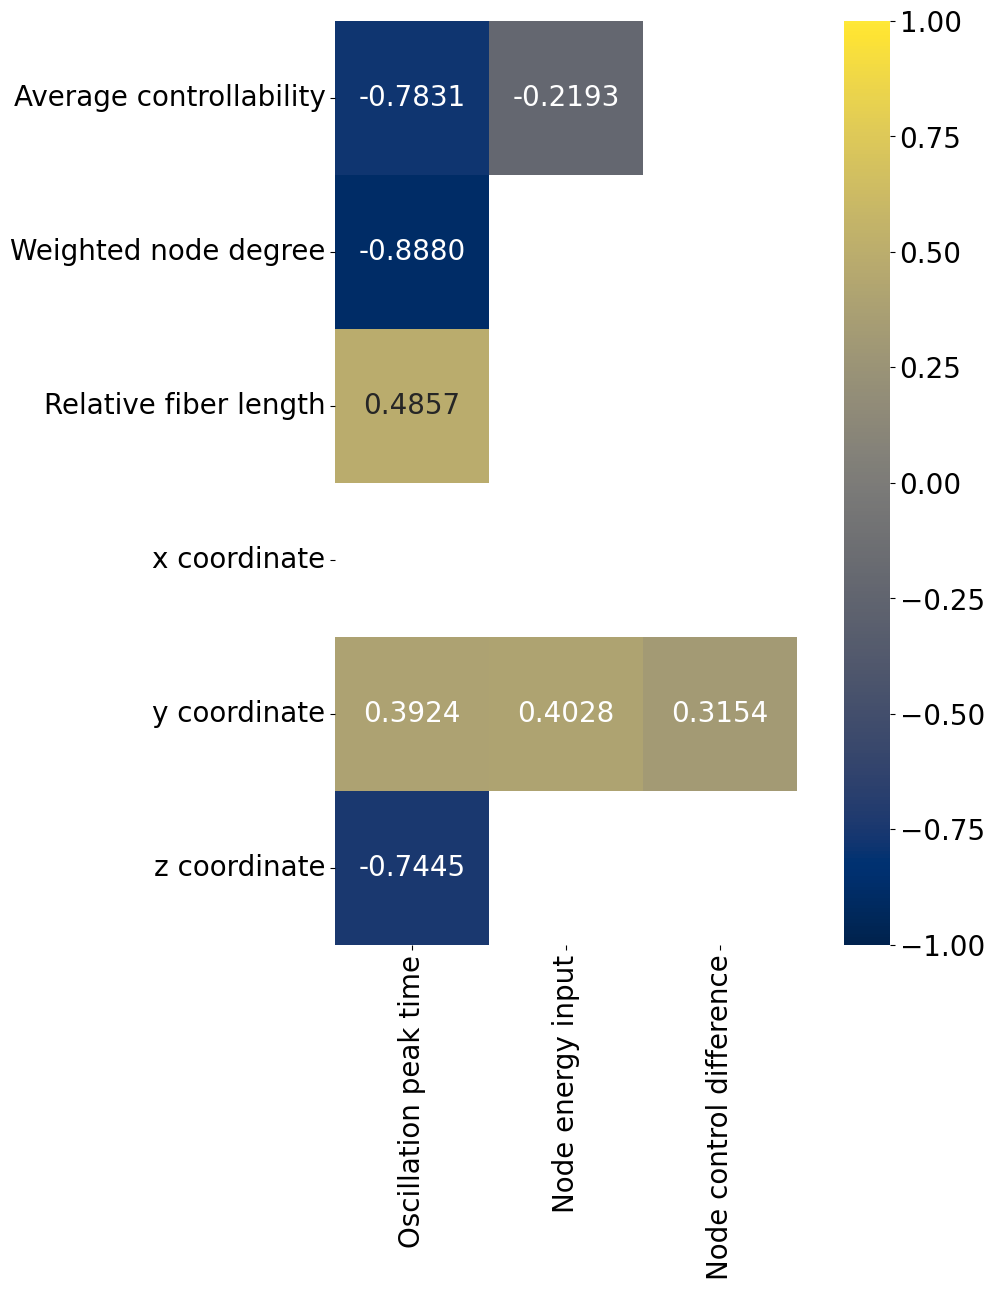

In [45]:
xlabel = ["Average controllability", "Weighted node degree", "Relative fiber length", "x coordinate", "y coordinate", "z coordinate"]
ylabel = ["Oscillation peak time", "Node energy input", "Node control difference"]

annotations = r_mat_sc_cd_0.copy()

for ix, x in enumerate(xlabel):
    for iy, y in enumerate(ylabel):
        if p_mat_sc_cd_0[ix, iy] >= 0.05:
            annotations[ix, iy] = None

for ix, x in enumerate(xlabel):
    for iy, y in enumerate(ylabel):
        if np.abs(r_mat_sc_cd_0[ix, iy]) < 0.0:
            annotations[ix, iy] = None

plt.figure(figsize=(12,12))
ax = sns.heatmap(annotations, annot=True, fmt='.4f', cmap=cmap, yticklabels=xlabel, xticklabels=ylabel, vmin=-1, vmax=1)
ax.set_aspect('equal', adjustable='box')
plt.savefig(os.path.join(datadir, "sc_cd_0.jpg"), bbox_inches='tight', dpi=300)
plt.show()

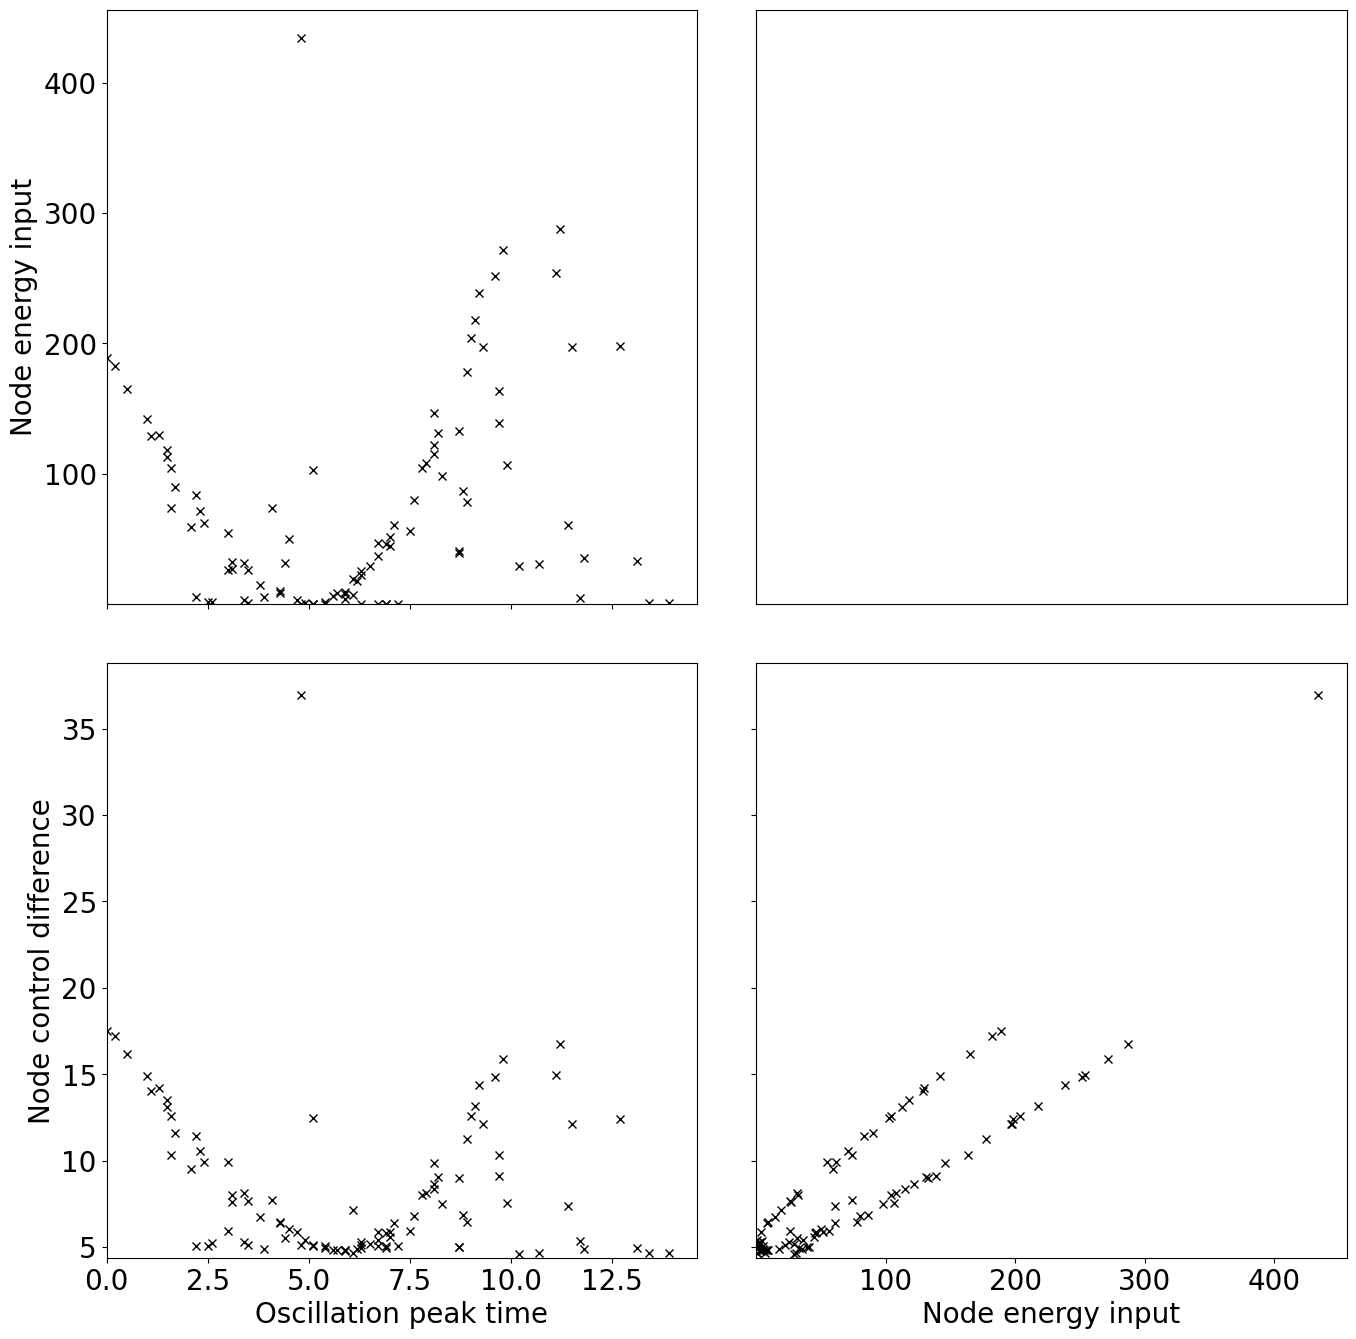

In [110]:
xlabel = ["Oscillation peak time", "Node energy input", "Node control difference"]

for wi in range(3):
    if wi != 1: continue
    
    fig, ax = plt.subplots(2,2, figsize=(16,16))

    x_array = [peak_times, energy_nodewise[wi,:], cnd[wi,:]]

    for ix, x in enumerate(x_array):
        for iy, y in enumerate(x_array):

            if ix == 2: continue

            a = ax[iy-1,ix]

            if ix >= iy:
                continue

            a.plot(x, y, marker="x", color="k", linestyle="none")

            x_axis = np.linspace(np.amin(x)*0.95, np.amax(x)*1.05, 100)
            y_axis = np.linspace(np.amin(y)*0.95, np.amax(y)*1.05, 100)
            
            a.set_xlim(x_axis[0], x_axis[-1])
            a.set_ylim(y_axis[0], y_axis[-1])

            if iy == 2:
                a.set_xlabel(xlabel[ix])
            else:
                a.set_xticklabels([])

            if ix == 0:
                a.set_ylabel(xlabel[iy])
            else:
                a.set_yticklabels([])


    ax[0,1].set_xticks([])
    ax[0,1].set_yticks([])

    plt.subplots_adjust(left=None, bottom=0.1, right=None, top=None, wspace=0.1, hspace=0.1)
    plt.savefig(os.path.join(datadir, "sc_sc_measures_0.jpg"), bbox_inches='tight', dpi=300)
    plt.show()

############ control task 1

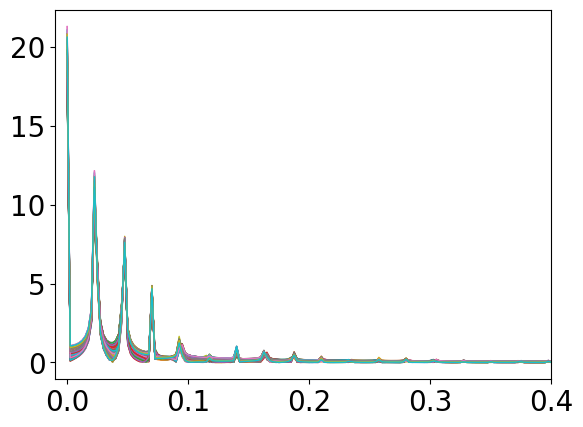

In [39]:
#### do peak times make sense?
import scipy.fftpack

state = data_1["state_uncontrolled"][:,0,:]
T = data_1["state_uncontrolled"][0].shape[1]
x = np.linspace(0.0, T*dt, T)
fig, ax = plt.subplots()

for n in range(N):

    yf = scipy.fftpack.fft(state[n,:])
    xf = np.linspace(0.0, 1.0/(2.0*dt), T//2)

    ax.plot(xf, 2.0/N * np.abs(yf[:T//2]))

ax.set_xlim(-0.01, 0.4)    
plt.show()

0.0 0.5517868817317624
0.0 0.6878132131980496
0.0 1.866640632436246
[[9, 17, 52, 60, 61, 67, 71, 73, 74, 80, 82, 83, 85, 89, 92, 96], [15, 17, 71], [2, 21, 23, 58]]
[21  2 58]


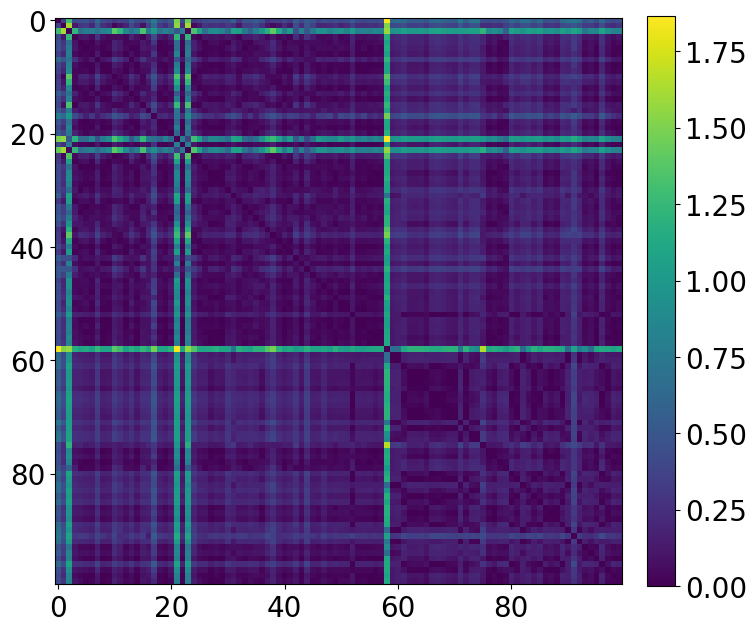

In [33]:
peak_times = np.zeros((N))

for n in range(N):
    peak_times[n] = scipy.signal.find_peaks(data_1["state_uncontrolled"][n,0,:1240], height=0.7)[0][-2]

peak_times -= np.amin(peak_times)
peak_times *= dt

peak_times1 = peak_times.copy()

energy_nodewise = np.zeros((3,N))
input_nodewise = np.zeros((3,N))
for wi in range(3):
    for n in range(N):
        energy_nodewise[wi,n] = np.sum(data_1["control"][wi][n,0,:])**2 * dt
        input_nodewise[wi,n] = np.sum(np.abs(data_1["control"][wi][n,0,:])) * dt

men = np.argsort(energy_nodewise)[2,-3:]

distmat = np.zeros((3,N,N))
cnd = np.zeros((3,N))
mdn = [[], [], []]

for wi in range(3):
    for n1 in range(N):
        for n2 in range(n1+1, N):
            distmat[wi,n1,n2] = np.sum( (data_1["control"][wi][n1,0,:] - data_1["control"][wi][n2,0,:])**2 )*dt
            distmat[wi,n2,n1] = distmat[wi,n1,n2].copy()

    cnd[wi,:] = np.sum(distmat[wi,:,:], axis=0)
    
    maxdist = np.amax(cnd[wi,:])
    for n in range(N):
        if cnd[wi,n] > 0.5*maxdist:
            mdn[wi].append(n)
        
    print(np.amin(distmat[wi,:,:]), np.amax(distmat[wi,:,:]))
print(mdn)

print(np.argsort(cnd[2,:])[-3:])

fig, ax = plt.subplots(1,1, figsize=(8,8))
heatmap = ax.imshow(distmat[2,:,:])
bar = plt.colorbar(heatmap, fraction=0.046, pad=0.04)
plt.show()

In [34]:

x_array = [av_c, wnd, nfl, coord_data[:,0], coord_data[:,1], coord_data[:,2]]
xlabel = ["Average controllability", "Weighted node degree", "Relative fiber length", "x coordinate", "y coordinate", "z coordinate" ]
ylabel = ["Oscillation peak time", "Node energy input", "Node control difference"]

wi = 2
y_array = [peak_times1, energy_nodewise[wi,:], cnd[wi,:]]

r_mat_sc_cd_1 = np.zeros((len(x_array), len(y_array)))
p_mat_sc_cd_1 = np.zeros((len(x_array), len(y_array)))

for ix, x in enumerate(x_array):
    for iy, y in enumerate(y_array):

        result = scipy.stats.pearsonr(x, y, method=method)
        r_val = result.statistic
        p_val = result.pvalue
        r_mat_sc_cd_1[ix, iy] = r_val
        p_mat_sc_cd_1[ix, iy] = p_val

if False:

    fig, ax = plt.subplots(3,len(x_array), figsize=(5*len(x_array), 20))

    y_array = [peak_times, energy_nodewise[wi,:], cnd[wi,:]]

    for ix, x in enumerate(x_array):

        for iy, y in enumerate(y_array):

            a = ax[iy, ix]

            a.plot(x, y, marker="x", color="k", linestyle="none")
            x_axis = np.linspace(np.amin(x)*0.95, np.amax(x)*1.05, 100)
            
            a.plot(x[mdn[wi]], y[mdn[wi]], marker="o", color="green", linestyle="none", markersize=10)

            result = scipy.stats.pearsonr(x, y, method=method)
            r_val = result.statistic
            p_val = result.pvalue
            corrstr = " r = {0:.3f}, p = {1:.3f}".format(r_val, p_val)

            a.text(0.9, 0.9, corrstr, horizontalalignment='right', verticalalignment='center', transform=a.transAxes)

            if p_val < 0.05 and np.abs(r_val) > 0.4:

                linfit, linfitcov = np.polyfit(x, y, 1, cov=True)
                linfitstd = np.sqrt(np.diag(linfitcov))
            
                if np.sign(linfit[0]) < 0:
                    a.plot(x_axis, linfit[1] + x_axis*linfit[0], color="red", label= r"$y = $" + "{:.2f}".format(linfit[1]) + r"$-$" + "{:.2f}".format(-linfit[0]) + "$\cdot x$", zorder=-1)
                else:
                    a.plot(x_axis, linfit[1] + x_axis*linfit[0], color="red", label= r"$y = $" + "{:.2f}".format(linfit[1]) + r"$+$" + "{:.2f}".format(linfit[0]) + "$\cdot x$", zorder=-1)
                ploterrorrange(x_axis, linfit, linfitstd)
                                    
                a.set_xlim(x_axis[0], x_axis[-1])
                a.set_ylim(0, np.amax(y)*1.05)
            
            if iy == 2:
                a.set_xlabel(xlabel[ix])
            else:
                a.set_xticklabels([])

            if ix == 0:
                a.set_ylabel(ylabel[iy])
            else:
                a.set_yticklabels([])
                
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.1, hspace=0.1)
    plt.savefig(os.path.join(datadir, "sc_cd_measures_1.jpg"), bbox_inches='tight', dpi=300)
    plt.show()


if False:
    x_array = [coord_data[:,2], coord_data[:,0]]
    y_array = [peak_times, energy_nodewise[wi,:]]
    xlabel = ["z coordinate", "x coordinate"]
    ylabel = ["Oscillation peak time", "Node energy input"]

    wi = 2

    fig, ax = plt.subplots(len(y_array),len(x_array), figsize=(5*len(x_array), 5*len(y_array)))

    for ix, x in enumerate(x_array):

        for iy, y in enumerate(y_array):
            a = ax[iy, ix]

            if [iy, ix] != [1,0]:

                a.plot(x, y, marker="x", color="k", linestyle="none", zorder=0)
                x_axis = np.linspace(np.amin(x)*0.95, np.amax(x)*1.05, 100)
                
                a.plot(x[mdn[wi]], y[mdn[wi]], marker="o", color="green", linestyle="none", markersize=9, zorder=2)
                a.plot(x[men], y[men], marker="o", color="red", linestyle="none", markersize=12, zorder=1)
                

                result = scipy.stats.pearsonr(x, y, method=method)
                r_val = result.statistic
                p_val = result.pvalue
                corrstr = " r = {0:.3f}, p = {1:.3f}".format(r_val, p_val)
                a.text(0.9, 0.9, corrstr, horizontalalignment='right', verticalalignment='center', transform=a.transAxes)
            
                linfit, linfitcov = np.polyfit(x, y, 1, cov=True)
                linfitstd = np.sqrt(np.diag(linfitcov))
                #print(linfit, np.sqrt(np.diag(linfitcov)))

                if np.sign(linfit[0]) < 0:
                    a.plot(x_axis, linfit[1] + x_axis*linfit[0], color="red", label= r"$y = $" + "{:.2f}".format(linfit[1]) + r"$-$" + "{:.2f}".format(-linfit[0]) + "$\cdot x$", zorder=-1)
                else:
                    a.plot(x_axis, linfit[1] + x_axis*linfit[0], color="red", label= r"$y = $" + "{:.2f}".format(linfit[1]) + r"$+$" + "{:.2f}".format(linfit[0]) + "$\cdot x$", zorder=-1)
                ploterrorrange(x_axis, linfit, linfitstd)
                        
            a.set_xlim(x_axis[0], x_axis[-1])
            a.set_ylim(0, np.amax(y)*1.05)
            
            if iy == 1:
                a.set_xlabel(xlabel[ix])
            else:
                a.set_xticklabels([])

            if ix == 0:
                a.set_ylabel(ylabel[iy])
            else:
                a.set_yticklabels([])
                
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.1, hspace=0.1)
    plt.savefig(os.path.join(datadir, "sc_cd_measures_1.jpg"), bbox_inches='tight', dpi=300)
    plt.show()

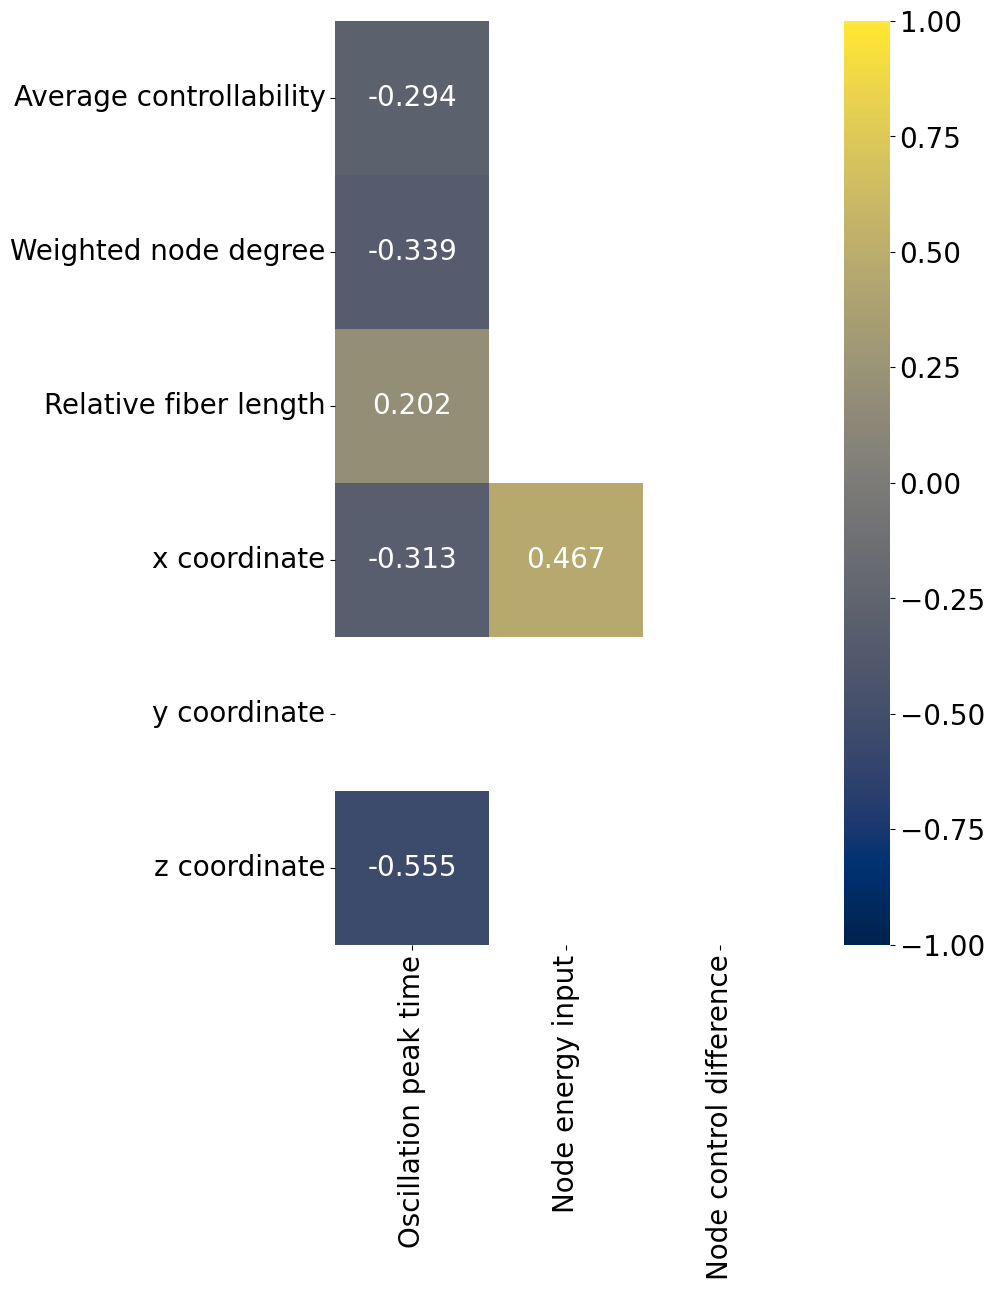

In [46]:
xlabel = ["Average controllability", "Weighted node degree", "Relative fiber length", "x coordinate", "y coordinate", "z coordinate" ]
ylabel = ["Oscillation peak time", "Node energy input", "Node control difference"]

annotations = r_mat_sc_cd_1.copy()

for ix, x in enumerate(xlabel):
    for iy, y in enumerate(ylabel):
        if p_mat_sc_cd_1[ix, iy] >= 0.05:
            annotations[ix, iy] = None

for ix, x in enumerate(xlabel):
    for iy, y in enumerate(ylabel):
        if np.abs(r_mat_sc_cd_1[ix, iy]) < 0.0:
            annotations[ix, iy] = None

plt.figure(figsize=(12,12))
ax = sns.heatmap(annotations, annot=True, fmt='.3f', cmap=cmap, yticklabels=xlabel, xticklabels=ylabel, vmin=-1, vmax=1)
ax.set_aspect('equal', adjustable='box')
plt.savefig(os.path.join(datadir, "sc_cd_1.jpg"), bbox_inches='tight', dpi=300)
plt.show()

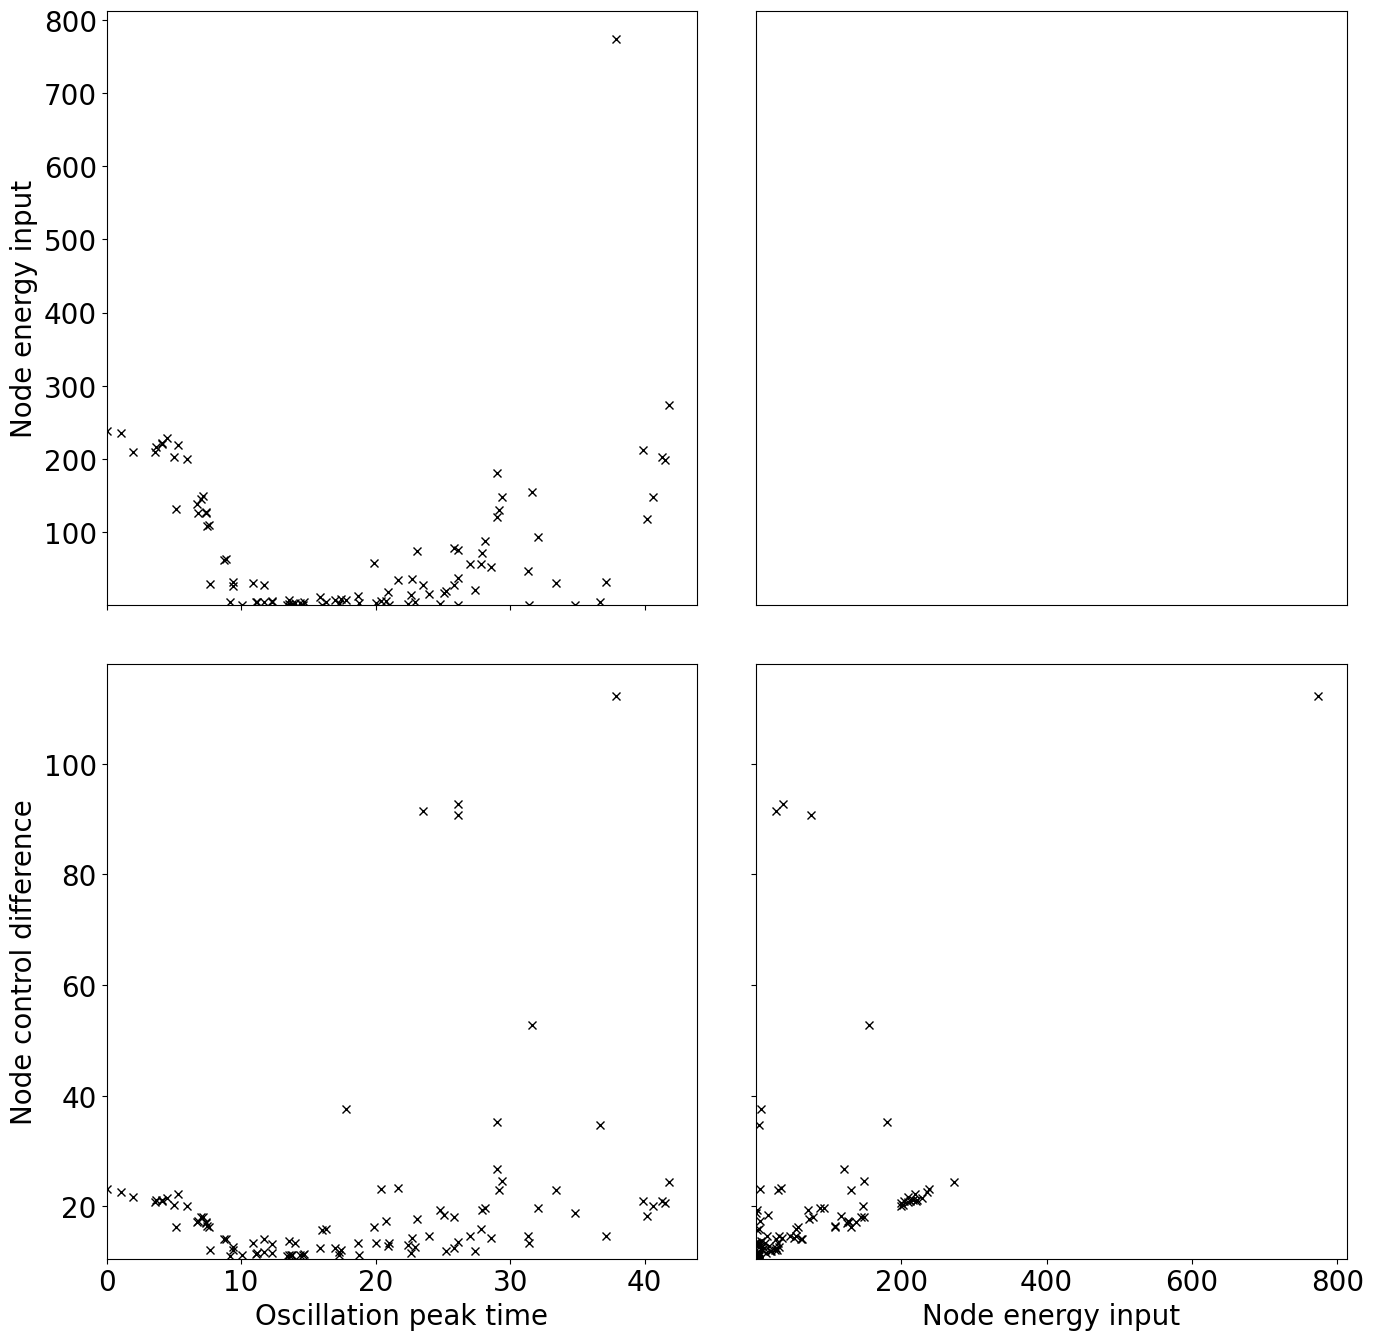

In [106]:
xlabel = ["Oscillation peak time", "Node energy input", "Node control difference"]

wi = 2

fig, ax = plt.subplots(2,2, figsize=(16,16))

x_array = [peak_times, energy_nodewise[wi,:], cnd[wi,:]]

for ix, x in enumerate(x_array):
    for iy, y in enumerate(x_array):

        if ix == 2: continue

        a = ax[iy-1,ix]

        if ix >= iy:
            continue

        a.plot(x, y, marker="x", color="k", linestyle="none")

        x_axis = np.linspace(np.amin(x)*0.95, np.amax(x)*1.05, 100)
        y_axis = np.linspace(np.amin(y)*0.95, np.amax(y)*1.05, 100)
        
        a.set_xlim(x_axis[0], x_axis[-1])
        a.set_ylim(y_axis[0], y_axis[-1])

        if iy == 2:
            a.set_xlabel(xlabel[ix])
        else:
            a.set_xticklabels([])

        if ix == 0:
            a.set_ylabel(xlabel[iy])
        else:
            a.set_yticklabels([])


ax[0,1].set_xticks([])
ax[0,1].set_yticks([])

plt.subplots_adjust(left=None, bottom=0.1, right=None, top=None, wspace=0.1, hspace=0.1)
plt.savefig(os.path.join(datadir, "sc_sc_measures_1.jpg"), bbox_inches='tight', dpi=300)
plt.show()

################# control task 2

[90 50 79]
0.0 2.3136931778054306
0.0 2.3136931778054306
0.0 2.0828112510712034
[[49, 50, 52, 54, 55, 56, 75, 79, 85], [49, 50, 52, 54, 55, 56, 75, 79, 85], [36, 50, 55, 68, 79, 85, 90, 91, 98]]


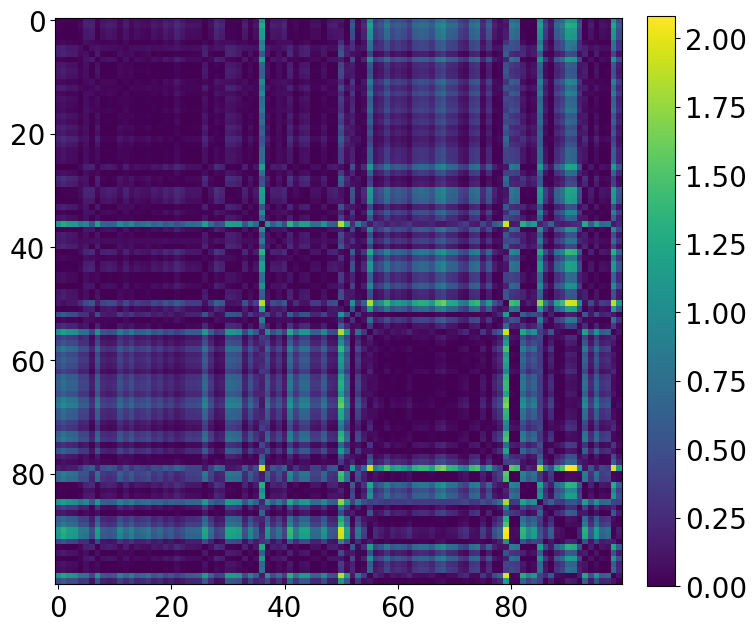

In [38]:
peak_times = np.zeros((N))

for n in range(N):
    peak_times[n] = scipy.signal.find_peaks(data_2["state_uncontrolled"][n,0,:], height=0.7)[0][-1]

peak_times -= np.amin(peak_times)
peak_times *= dt

peak_times2 = peak_times.copy()

peak_time_order2 = np.argsort(peak_times)

energy_nodewise = np.zeros((3,N))
input_nodewise = np.zeros((3,N))
for wi in range(3):
    for n in range(N):
        energy_nodewise[wi,n] = np.sum(data_2["control"][wi][n,0,:])**2 * dt
        input_nodewise[wi,n] = np.sum(data_2["control"][wi][n,0,:]) * dt

men = np.argsort(energy_nodewise)[2,-3:]
print(men)

distmat = np.zeros((3,N,N))
cnd = np.zeros((3,N))
mdn = [[], [], []]

for wi in range(3):
    for n1 in range(N):
        for n2 in range(n1+1, N):
            distmat[wi,n1,n2] = np.sum( (data_2["control"][wi][n1,0,:] - data_2["control"][wi][n2,0,:])**2 )*dt
            distmat[wi,n2,n1] = distmat[wi,n1,n2].copy()

    cnd[wi,:] = np.sum(distmat[wi,:,:], axis=0)
    
    maxdist = np.amax(cnd[wi,:])
    for n in range(N):
        if cnd[wi,n] > 0.55*maxdist:
            mdn[wi].append(n)
        
    print(np.amin(distmat[wi,:,:]), np.amax(distmat[wi,:,:]))
print(mdn)

fig, ax = plt.subplots(1,1, figsize=(8,8))
heatmap = ax.imshow(distmat[2,:,:])
bar = plt.colorbar(heatmap, fraction=0.046, pad=0.04)
plt.show()

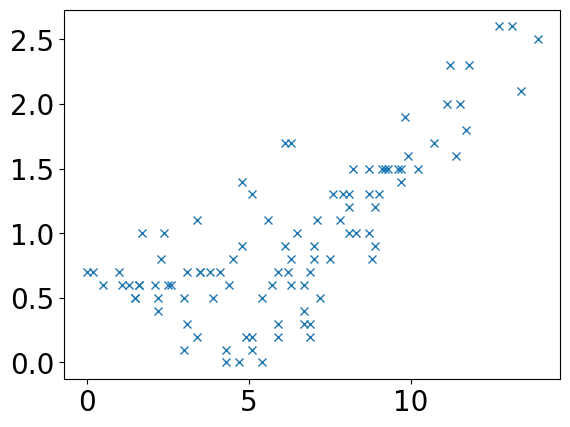

In [28]:
plt.plot(peak_times0, peak_times2, linestyle="none", marker="x")

In [29]:
x_array = [av_c, wnd, nfl, coord_data[:,0], coord_data[:,1], coord_data[:,2]]
xlabel = ["Average controllability", "Weighted node degree", "Relative fiber length", "x coordinate", "y coordinate", "z coordinate"]
ylabel = ["Oscillation peak time", "Node energy input", "Node control difference"]

wi = 2
y_array = [peak_times2, energy_nodewise[wi,:], cnd[wi,:]]

r_mat_sc_cd_2 = np.zeros((len(x_array), len(y_array)))
p_mat_sc_cd_2 = np.zeros((len(x_array), len(y_array)))

for ix, x in enumerate(x_array):
    for iy, y in enumerate(y_array):

        result = scipy.stats.pearsonr(x, y, method=method)
        r_val = result.statistic
        p_val = result.pvalue
        r_mat_sc_cd_2[ix, iy] = r_val
        p_mat_sc_cd_2[ix, iy] = p_val

if False:

    fig, ax = plt.subplots(3,len(x_array), figsize=(5*len(x_array), 20))

    y_array = [peak_times, energy_nodewise[wi,:], cnd[wi,:]]

    for ix, x in enumerate(x_array):

        for iy, y in enumerate(y_array):

            a = ax[iy, ix]

            a.plot(x, y, marker="x", color="k", linestyle="none")
            x_axis = np.linspace(np.amin(x)*0.95, np.amax(x)*1.05, 100)
            
            a.plot(x[mdn[wi]], y[mdn[wi]], marker="o", color="green", linestyle="none", markersize=9, zorder=2)
            a.plot(x[men], y[men], marker="o", color="red", linestyle="none", markersize=12, zorder=1)

            result = scipy.stats.pearsonr(x, y, method=method)
            r_val = result.statistic
            p_val = result.pvalue
            corrstr = " r = {0:.3f}, p = {1:.3f}".format(r_val, p_val)

            a.text(0.9, 0.9, corrstr, horizontalalignment='right', verticalalignment='center', transform=a.transAxes)

            if p_val < 0.05 and np.abs(r_val) > 0.4:

                linfit, linfitcov = np.polyfit(x, y, 1, cov=True)
                linfitstd = np.sqrt(np.diag(linfitcov))

                if np.sign(linfit[0]) < 0:
                    a.plot(x_axis, linfit[1] + x_axis*linfit[0], color="red", label= r"$y = $" + "{:.2f}".format(linfit[1]) + r"$-$" + "{:.2f}".format(-linfit[0]) + "$\cdot x$", zorder=-1)
                else:
                    a.plot(x_axis, linfit[1] + x_axis*linfit[0], color="red", label= r"$y = $" + "{:.2f}".format(linfit[1]) + r"$+$" + "{:.2f}".format(linfit[0]) + "$\cdot x$", zorder=-1)
                ploterrorrange(x_axis, linfit, linfitstd)
                                    
                a.set_xlim(x_axis[0], x_axis[-1])
                a.set_ylim(0, np.amax(y)*1.05)
            
            if iy == 2:
                a.set_xlabel(xlabel[ix])
            else:
                a.set_xticklabels([])

            if ix == 0:
                a.set_ylabel(ylabel[iy])
            else:
                a.set_yticklabels([])
                
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.1, hspace=0.1)
    plt.savefig(os.path.join(datadir, "sc_cd_measures_2.jpg"), bbox_inches='tight', dpi=300)
    plt.show()

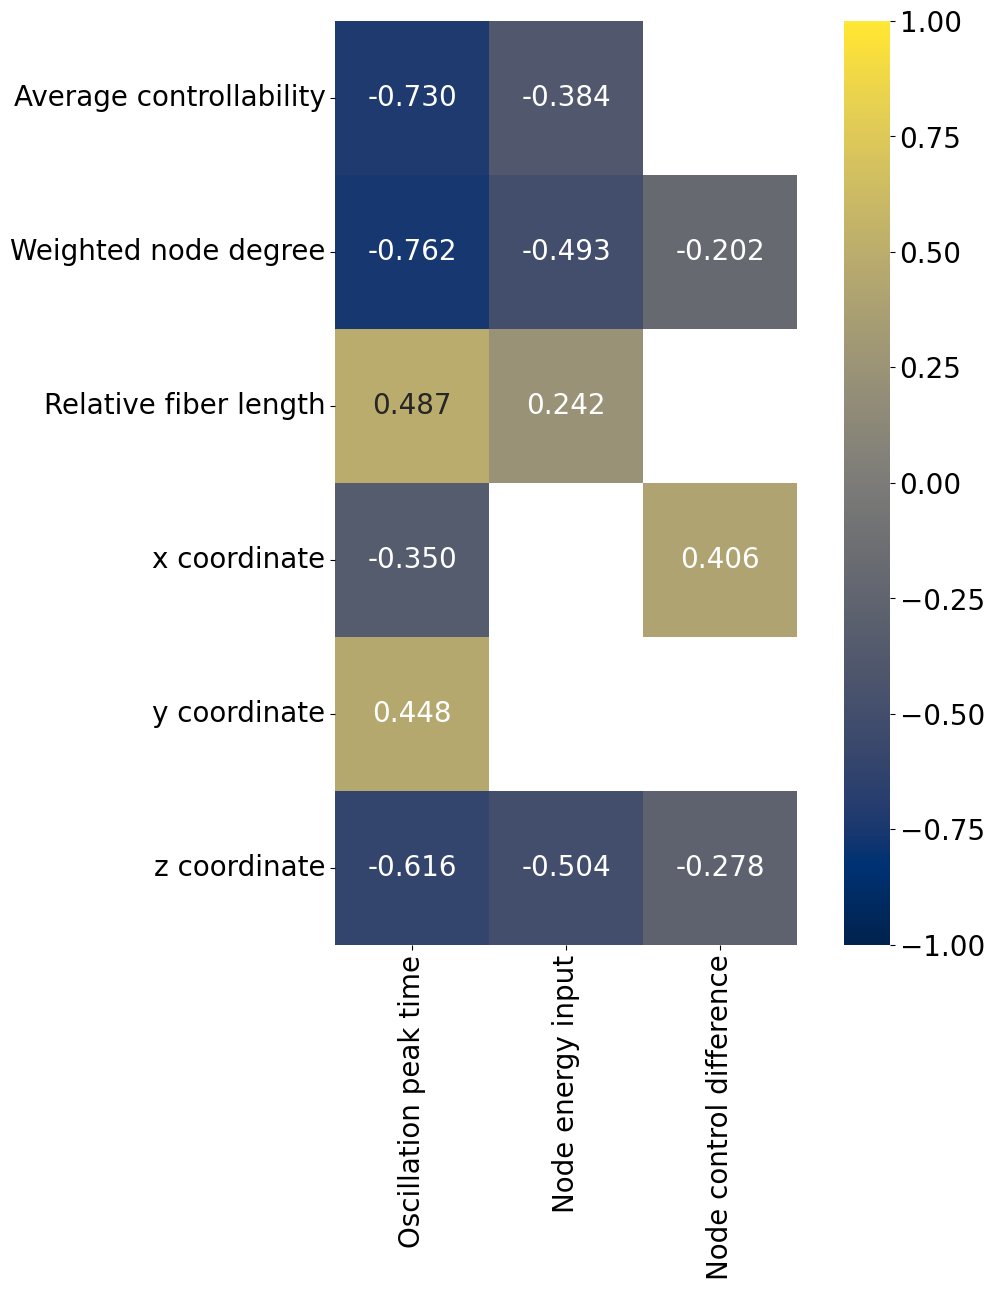

In [47]:
xlabel = ["Average controllability", "Weighted node degree", "Relative fiber length", "x coordinate", "y coordinate", "z coordinate" ]
ylabel = ["Oscillation peak time", "Node energy input", "Node control difference"]

annotations = r_mat_sc_cd_2.copy()

for ix, x in enumerate(xlabel):
    for iy, y in enumerate(ylabel):
        if p_mat_sc_cd_2[ix, iy] >= 0.05:
            annotations[ix, iy] = None

for ix, x in enumerate(xlabel):
    for iy, y in enumerate(ylabel):
        if np.abs(r_mat_sc_cd_2[ix, iy]) < 0.0:
            annotations[ix, iy] = None

plt.figure(figsize=(12,12))
ax = sns.heatmap(annotations, annot=True, fmt='.3f', cmap=cmap, yticklabels=xlabel, xticklabels=ylabel, vmin=-1, vmax=1)
ax.set_aspect('equal', adjustable='box')
plt.savefig(os.path.join(datadir, "sc_cd_2.jpg"), bbox_inches='tight', dpi=300)
plt.show()

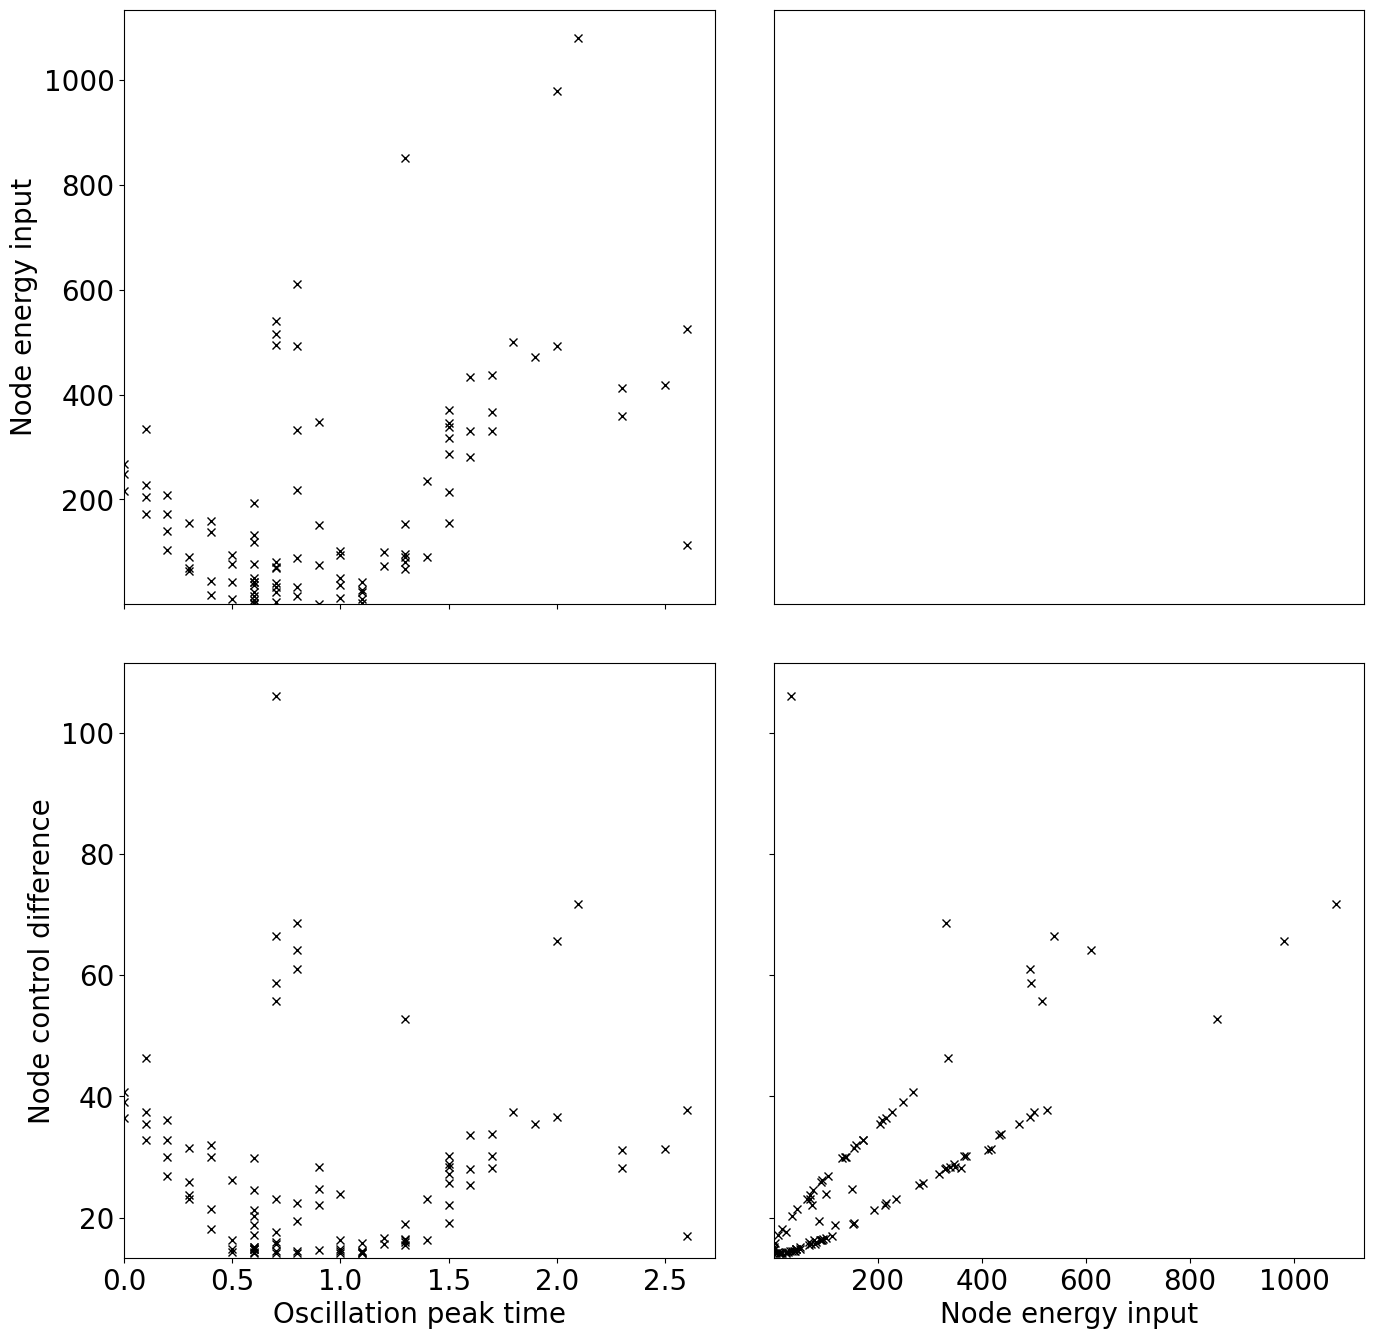

In [108]:
xlabel = ["Oscillation peak time", "Node energy input", "Node control difference"]

wi = 2
    
fig, ax = plt.subplots(2,2, figsize=(16,16))

x_array = [peak_times, energy_nodewise[wi,:], cnd[wi,:]]

for ix, x in enumerate(x_array):
    for iy, y in enumerate(x_array):

        if ix == 2: continue

        a = ax[iy-1,ix]

        if ix >= iy:
            continue

        a.plot(x, y, marker="x", color="k", linestyle="none")

        x_axis = np.linspace(np.amin(x)*0.95, np.amax(x)*1.05, 100)
        y_axis = np.linspace(np.amin(y)*0.95, np.amax(y)*1.05, 100)
        
        a.set_xlim(x_axis[0], x_axis[-1])
        a.set_ylim(y_axis[0], y_axis[-1])

        if iy == 2:
            a.set_xlabel(xlabel[ix])
        else:
            a.set_xticklabels([])

        if ix == 0:
            a.set_ylabel(xlabel[iy])
        else:
            a.set_yticklabels([])


ax[0,1].set_xticks([])
ax[0,1].set_yticks([])

plt.subplots_adjust(left=None, bottom=0.1, right=None, top=None, wspace=0.1, hspace=0.1)
plt.savefig(os.path.join(datadir, "sc_sc_measures_2.jpg"), bbox_inches='tight', dpi=300)
plt.show()